# Generator-level studies

## Impact of kinematic cuts

### Definition of kinematic cuts

It's not realistic to regress $\tau$ lepton decay products that we would never be able to detect.
This argument doesn't apply only to neutrinos but also to constituents that are very soft and/or out of geometric acceptance.

With geometric acceptance it's easy: we require $10^\degree < \theta < 170^\degree$ on the polar angle $\theta$ of any generator-level constituent (see Figure 11 and Section 7.2.2 of [this paper](https://inspirehep.net/literature/1767435)) or, equivalently, $|\cos\theta| < 0.99$, since this requirement roughly corresponds to the geometric coverage of the tracking system in CLD version of the FCC-ee.

We can use basic laws of physics to come up with a $p_T$ requirement to eliminate soft charged constituents.
In the absence of electric field, particles with charge $q$ and mass $m$ are subject to [Lorentz force](https://en.wikipedia.org/wiki/Lorentz_force) $\mathbf{F}_\mathrm{Lorentz}$ in magnetic field $\mathbf{B}$, which is perpendicular to their velocity $\mathbf{v}$: $\mathbf{F}_\mathrm{Lorentz} = q (\mathbf{v}\times\mathbf{B})$.
It's evident from this relation that only the component that is perpendicular to the magnetic field, $\mathbf{v}_T \perp \mathbf{B}$, contributes to this force.
We can estimate the radius of curvature $r$ of the path this charged particle takes by equating the magnitude of the Lorentz force to [centripetal force](https://en.wikipedia.org/wiki/Centripetal_force) $F_\mathrm{centripetal} = mv_T^2 / r$:

$$
qv_TB = \frac{mv_T^2}{r} \quad\Rightarrow\quad p_T = qBr\,,
$$

where $p_T \equiv mv_T$ stands for transverse momentum.
When a charged particle is created at the origin of the detector, it travels along a circular path in the azimuthal (i.e., transverse) plane.
The radius of its circular path is linearly proportional to its $p_T$.
If a charged particle has too low $p_T$, it might never reach the detector layers as its trajectory curls back towards the origin.
In that case the maximum distance $R$ that is reached by the charged particle is a full diameter away from its origin, i.e.,

$$
p_T = qB\frac{R}{2}\,.
$$

We can convert this expression from SI units to natural units by recognising that $[p_T] = \mathrm{eV}/c$ and $[q] = \mathrm{eV}$:

$$
p_T = 3\cdot10^8 B \frac{R}{2}\,[\mathrm{eV}] = 0.3 B \frac{R}{2}\,[\mathrm{GeV}]\,.
$$
Magnetic field in the CLD is $B = 2\,\mathrm{T}$, which cancels out the denominator, thus leaving us with:

$$
p_T = 0.3 R \,[\mathrm{GeV}]\,.
$$

We can use this condition to derive the $p_T$ requirement for charged particles that are too soft to be detected.

The loosest requirement one could think of is that the charged particle should reach at least the second layer of the tracker since we need at least two hits to reconstruct a path.
In CLD, the second tracker layer in the barrel is located at a radial distance of $R = 0.4$ meters (see Table 5 in the CLD paper), which translates to minimum $p_T$ requirement of $0.12\,\mathrm{GeV}$.
This requirement is consistent with the minimum $p_T$ requirement that is applied in, e.g., $H\to\tau\tau$ analysis in FCC-ee conditions (see Section 2 of [this paper](https://inspirehep.net/literature/3108543)) where the authors apply a minimum $p_T$ cut of $0.1\,\mathrm{GeV}$.
For our purposes we'll use the rounded down version of the cut.

These arguments do not apply to neutral hadrons.
The CLD paper also doesn't help us too much here because the authors study the energy resolution of $K_L^0$ meson but in fairly coarse bins.
The leftmost bins in Figure 40 of the paper extends to about 5 GeV, which seems a bit too high of an energy cut for our use case.
In the $H\to\tau\tau$ analysis referenced earlier, the authors apply a $p_T$ cut of $0.1\,\mathrm{GeV}$ on photons, which seems a bit too low of a cut for neutral hadrons.
Nevertheless, we'll stick to this conservative cut for the time being, and will raise it once we have a better idea of how the energy resolution degrades as a function of generator-level energy of neutral hadrons.

**Action item**: using the samples we have, determine energy resolution of neutral hadrons in bins of energy and polar angle.

It's an open point as to whether we should apply the cut on $p_T$ or energy of neutral hadrons.
Since $p_T\sim E\sin\theta$, applying a $p_T$ cut on forward hadrons will effectively require the hadrons to be more energetic.
Then again, we expect beam-induced background in the forward region (see the discussion in Section 5.4 of the CLD paper) which might interfere with our $\tau$ reconstruction and identification task.
In that case it's easier to just apply the $p_T$ cut.

In conclusion, we'll apply the following cuts on generator-level hadronic $\tau$ decay products: $|\cos\theta|<0.99$ and $p_T > 0.1\,\mathrm{GeV}$.

### Impact of kinematic cuts on charge misassignment

In [1]:
import pandas as pd
import os.path

In [2]:
run_basename = '20260922_ParTauDETR_120epochs'

obj_cls_trsh = 0.5
obj_cls_trsh_str = f'{obj_cls_trsh:.3f}'.replace('.', 'p')

fn = os.path.expanduser(f'~/tmp/{run_basename}-model_best-{obj_cls_trsh_str}thr.parquet')

df = pd.read_parquet(fn)

In [3]:
import particle

explicit_dms = [0, 1, 2, 10, 11, 12]
labels = explicit_dms + ["Rare"]
predicted_labels = labels + ["Invalid"]


def normalize_truth_dm(dm):
    return dm if dm in explicit_dms else "Rare"


def predict_dm(pdg_ids):
    charges = [ particle.pdgid.charge(pdg_id) for pdg_id in pdg_ids ]
    n_neutral = sum(charge == 0 for charge in charges)
    n_charged = len(charges) - n_neutral
    if n_charged % 2 == 0 or n_neutral > 4:
        return "Invalid"
    dm = 5 * (n_charged - 1) + n_neutral
    return dm if dm in explicit_dms else "Rare"


df["gen_tau_dm"] = df["gen_jet_tau_decaymode"].map(normalize_truth_dm)

In [4]:
df["gen_tau_dm"].value_counts()

gen_tau_dm
1       242934
0       109060
10       91977
2        86044
11       42981
Rare     13263
12        4534
Name: count, dtype: int64

In [5]:
df["gen_jet_tau_vis_daughter_pdgs"].map(predict_dm).value_counts()

gen_jet_tau_vis_daughter_pdgs
1          241375
0          109060
10          91973
2           87603
11          42909
Rare        13226
12           4603
Invalid        44
Name: count, dtype: int64

In [6]:
assert(not any(df['gen_jet_tau_vis_daughter_charges'].apply(lambda charges: sum(int(charge) for charge in charges)).astype(int) != df['gen_jet_tau_charge'].astype(int)))

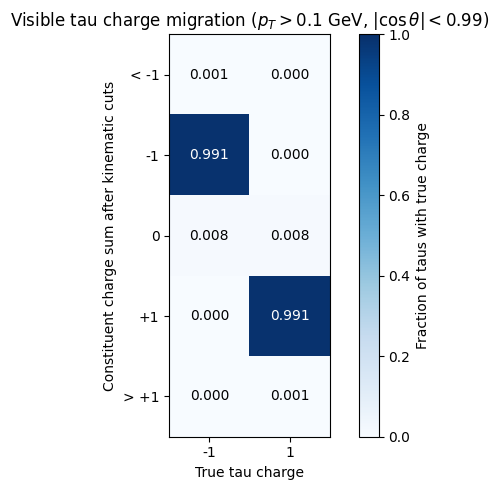

In [7]:
import matplotlib.pyplot as plt
import numpy as np

pt_min = 0.1  # GeV
max_abs_cos_theta = 0.99
true_charge_categories = [-1, 1]
reconstructed_charge_categories = ["< -1", "-1", "0", "+1", "> +1"]


def kinematic_mask(daughter_p4s):
    pt = np.asarray([daughter_p4["pt"] for daughter_p4 in daughter_p4s])
    eta = np.asarray([daughter_p4["eta"] for daughter_p4 in daughter_p4s])
    return (pt > pt_min) & (np.abs(np.tanh(eta)) < max_abs_cos_theta)


def reconstructed_charge_bin(charge_sum):
    if charge_sum < -1:
        return "< -1"
    if charge_sum > 1:
        return "> +1"
    return f"{charge_sum:+d}" if charge_sum else "0"


migration = np.zeros(
    (len(reconstructed_charge_categories), len(true_charge_categories)), dtype=int
)

for daughter_p4s, daughter_charges, true_charge in df[[
    "gen_jet_tau_vis_daughter_p4s",
    "gen_jet_tau_vis_daughter_charges",
    "gen_jet_tau_charge",
]].itertuples(index=False, name=None):
    daughter_charges = np.asarray(daughter_charges, dtype=int)

    if len(daughter_p4s) != len(daughter_charges):
        raise ValueError("Daughter p4 and charge arrays must have equal lengths.")
    if true_charge not in true_charge_categories:
        raise ValueError(f"Unexpected true tau charge: {true_charge}")

    selected = kinematic_mask(daughter_p4s)
    reconstructed_charge = int(daughter_charges[selected].sum())

    row = reconstructed_charge_categories.index(
        reconstructed_charge_bin(reconstructed_charge)
    )
    column = true_charge_categories.index(int(true_charge))
    migration[row, column] += 1


migration_normalized = migration / migration.sum(axis=0, keepdims=True)
migration_for_plot = np.ma.masked_where(migration == 0, migration_normalized)
cmap = plt.colormaps["Blues"].copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(migration_for_plot, cmap=cmap, vmin=0, vmax=1)
ax.set(
    xticks=range(len(true_charge_categories)),
    xticklabels=[str(charge) for charge in true_charge_categories],
    yticks=range(len(reconstructed_charge_categories)),
    yticklabels=reconstructed_charge_categories,
    xlabel="True tau charge",
    ylabel="Constituent charge sum after kinematic cuts",
    title=r"Visible tau charge migration ($p_T > 0.1$ GeV, $|\cos\theta| < 0.99$)",
)

for (row, column), fraction in np.ndenumerate(migration_normalized):
    ax.text(
        column,
        row,
        f"{fraction:.3f}",
        ha="center",
        va="center",
        color="white" if fraction > 0.5 else "black",
    )

fig.colorbar(image, ax=ax, label="Fraction of taus with true charge")
fig.tight_layout()
plt.show()
plt.close()

### Impact of kinematic cuts on decay mode misassignment

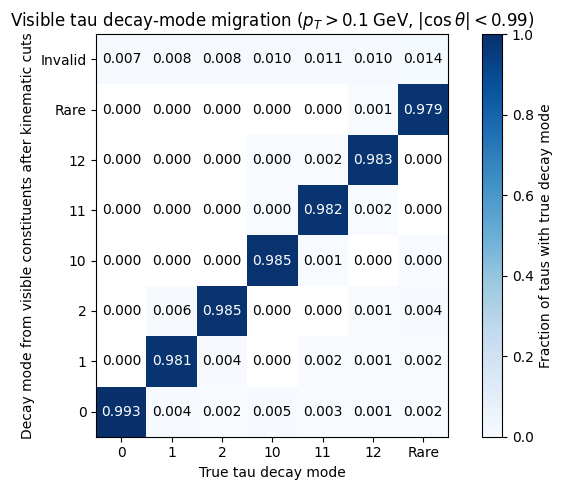

In [8]:
true_decay_mode_categories = labels
reconstructed_decay_mode_categories = list(reversed(predicted_labels))

migration = np.zeros(
    (len(reconstructed_decay_mode_categories), len(true_decay_mode_categories)),
    dtype=int,
)

for daughter_p4s, daughter_pdgs, true_decay_mode in df[[
    "gen_jet_tau_vis_daughter_p4s",
    "gen_jet_tau_vis_daughter_pdgs",
    "gen_tau_dm",
]].itertuples(index=False, name=None):
    if len(daughter_p4s) != len(daughter_pdgs):
        raise ValueError("Daughter p4 and PDG ID arrays must have equal lengths.")
    if true_decay_mode not in true_decay_mode_categories:
        raise ValueError(f"Unexpected true tau decay mode: {true_decay_mode}")

    selected = kinematic_mask(daughter_p4s)
    reconstructed_decay_mode = predict_dm(np.asarray(daughter_pdgs)[selected])

    row = reconstructed_decay_mode_categories.index(reconstructed_decay_mode)
    column = true_decay_mode_categories.index(true_decay_mode)
    migration[row, column] += 1


migration_normalized = migration / migration.sum(axis=0, keepdims=True)
migration_for_plot = np.ma.masked_where(migration == 0, migration_normalized)
cmap = plt.colormaps["Blues"].copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(migration_for_plot, cmap=cmap, vmin=0, vmax=1)
ax.set(
    xticks=range(len(true_decay_mode_categories)),
    xticklabels=true_decay_mode_categories,
    yticks=range(len(reconstructed_decay_mode_categories)),
    yticklabels=reconstructed_decay_mode_categories,
    xlabel="True tau decay mode",
    ylabel="Decay mode from visible constituents after kinematic cuts",
    title=r"Visible tau decay-mode migration ($p_T > 0.1$ GeV, $|\cos\theta| < 0.99$)",
)

for (row, column), fraction in np.ndenumerate(migration_normalized):
    ax.text(
        column,
        row,
        f"{fraction:.3f}",
        ha="center",
        va="center",
        color="white" if fraction > 0.5 else "black",
    )

fig.colorbar(image, ax=ax, label="Fraction of taus with true decay mode")
fig.tight_layout()
plt.show()
plt.close()

In [9]:
charge_mask = df.apply(
    lambda row: np.asarray(row["gen_jet_tau_vis_daughter_charges"])[
        kinematic_mask(row["gen_jet_tau_vis_daughter_p4s"])
    ].sum()
    == row["gen_jet_tau_charge"],
    axis="columns",
)

decay_mode_mask = df.apply(
    lambda row: predict_dm(
        np.asarray(row["gen_jet_tau_vis_daughter_pdgs"])[
            kinematic_mask(row["gen_jet_tau_vis_daughter_p4s"])
        ]
    )
    == row["gen_tau_dm"],
    axis="columns",
)

In [10]:
kinematic_cut_mask = df["gen_jet_tau_vis_daughter_p4s"].map(kinematic_mask).map(np.all)
quality_mask = charge_mask & decay_mode_mask

for label, mask in {
    "Kinematic cuts": kinematic_cut_mask,
    "Kinematic and quality cuts": kinematic_cut_mask & quality_mask,
}.items():
    lost = len(df) - mask.sum()
    print(f"{label}: lose {lost:,} / {len(df):,} taus ({lost / len(df):.2%})")

Kinematic cuts: lose 7,547 / 590,793 taus (1.28%)
Kinematic and quality cuts: lose 9,196 / 590,793 taus (1.56%)


### Impact of kinematic cuts on visible tau 4-momentum

In [11]:
epsilon = 1e-4


def p4_to_cartesian(p4):
    pt = p4["pt"]
    phi = p4["phi"]
    return np.array(
        [
            pt * np.cos(phi),
            pt * np.sin(phi),
            pt * np.sinh(p4["eta"]),
            p4["energy"],
        ]
    )


for tau_p4, daughter_p4s in df[[
    "gen_jet_tau_p4",
    "gen_jet_tau_vis_daughter_p4s",
]].itertuples(index=False, name=None):
    daughter_sum = np.sum(
        [p4_to_cartesian(daughter_p4) for daughter_p4 in daughter_p4s],
        axis=0,
    )
    np.testing.assert_allclose(
        p4_to_cartesian(tau_p4),
        daughter_sum,
        atol=epsilon,
        rtol=0,
    )

In [12]:
from matplotlib.colors import LogNorm


def cartesian_to_p4(cartesian_p4):
    px, py, pz, energy = cartesian_p4
    pt = np.hypot(px, py)
    mass = np.sqrt(max(energy**2 - px**2 - py**2 - pz**2, 0))
    return {
        "pt": pt,
        "eta": np.arcsinh(pz / pt) if pt else 0,
        "phi": np.arctan2(py, px),
        "mass": mass,
        "energy": energy,
    }


def selected_p4s(event_mask):
    reference_p4s = []
    test_p4s = []
    for tau_p4, daughter_p4s, keep_event in df[[
        "gen_jet_tau_p4",
        "gen_jet_tau_vis_daughter_p4s",
]].assign(keep_event=event_mask).itertuples(index=False, name=None):
        if not keep_event:
            continue

        selected_daughters = [
            p4_to_cartesian(daughter_p4)
            for daughter_p4, selected in zip(daughter_p4s, kinematic_mask(daughter_p4s))
            if selected
        ]
        reference_p4s.append(cartesian_to_p4(p4_to_cartesian(tau_p4)))
        test_p4s.append(
            cartesian_to_p4(
                np.sum(selected_daughters, axis=0) if selected_daughters else np.zeros(4)
            )
        )

    return (
        {key: np.asarray([p4[key] for p4 in reference_p4s]) for key in reference_p4s[0]},
        {key: np.asarray([p4[key] for p4 in test_p4s]) for key in test_p4s[0]},
    )


samples = {
    False: selected_p4s(np.ones(len(df), dtype=bool)),
    True: selected_p4s(charge_mask & decay_mode_mask),
}
variables = ["pt", "eta", "phi", "mass", "energy"]
variable_labels = {
    "pt": r"$p_T$ [GeV]",
    "eta": r"$\eta$",
    "phi": r"$\phi$",
    "mass": r"$m$ [GeV]",
    "energy": r"$E$ [GeV]",
}
migration_bins = {
    "pt": np.linspace(0, 45, 101),
    "eta": np.linspace(-3, 3, 101),
    "phi": np.linspace(-np.pi, np.pi, 101),
    "mass": np.linspace(0, 2, 101),
    "energy": np.linspace(0, 50, 101),
}

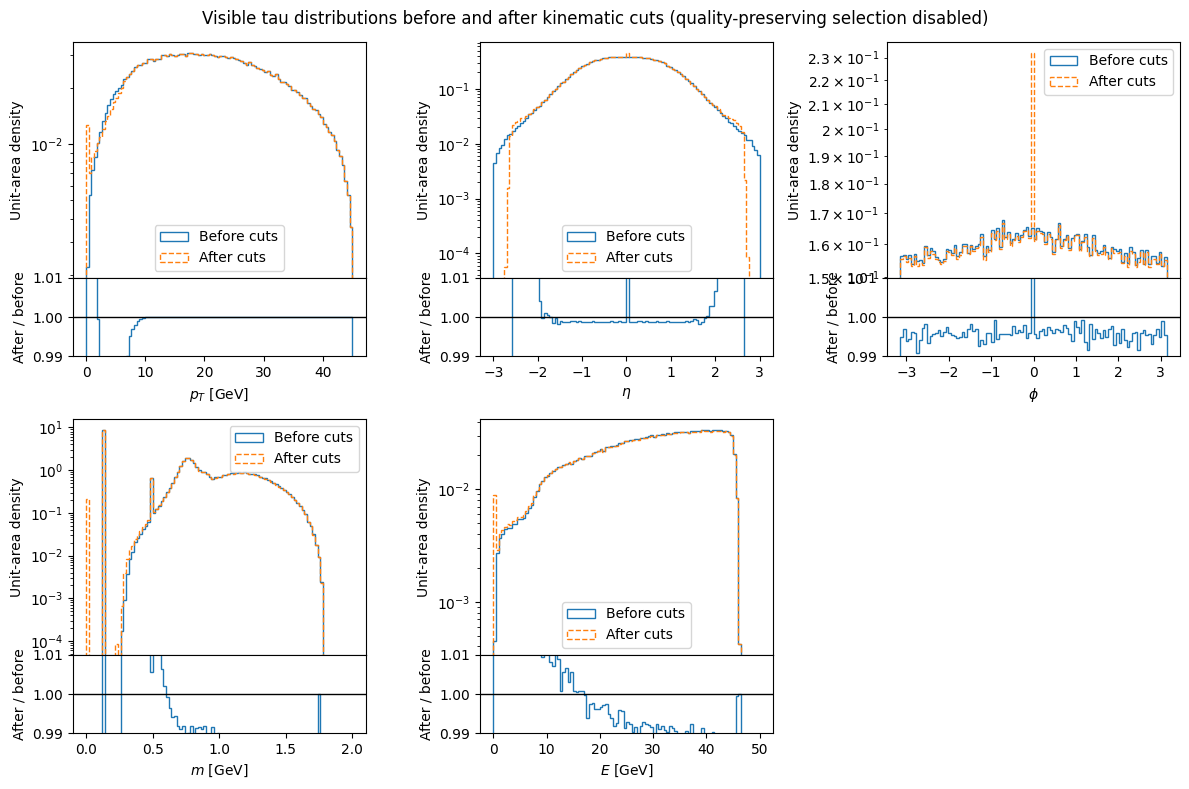

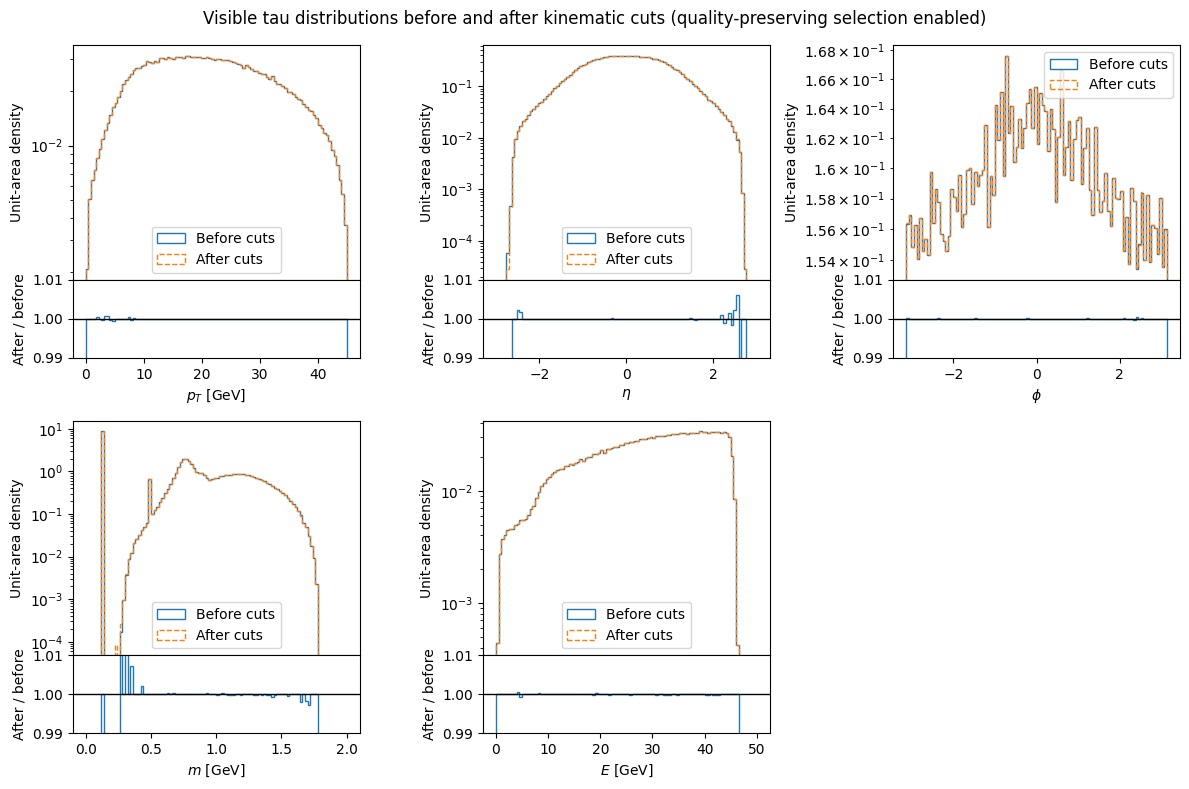

In [13]:
for apply_quality_masks, (reference, test) in samples.items():
    quality_selection = (
        "quality-preserving selection enabled"
        if apply_quality_masks
        else "quality-preserving selection disabled"
    )
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, variable in zip(axes.flat, variables):
        bins = migration_bins[variable]
        subplots = ax.get_subplotspec().subgridspec(
            2, 1, height_ratios=(3, 1), hspace=0
        )
        ax.remove()
        spectrum_ax = fig.add_subplot(subplots[0])
        ratio_ax = fig.add_subplot(subplots[1], sharex=spectrum_ax)
        reference_histogram, _ = np.histogram(
            reference[variable], bins=bins, density=True
        )
        test_histogram, _ = np.histogram(test[variable], bins=bins, density=True)
        spectrum_ax.hist(
            reference[variable],
            bins=bins,
            density=True,
            histtype="step",
            label="Before cuts",
        )
        spectrum_ax.hist(
            test[variable],
            bins=bins,
            density=True,
            histtype="step",
            label="After cuts",
            ls="--",
        )
        ratio = np.divide(
            test_histogram,
            reference_histogram,
            out=np.full_like(test_histogram, np.nan),
            where=reference_histogram != 0,
        )
        ratio_ax.stairs(ratio, bins)
        ratio_ax.axhline(1, color="black", linewidth=1)
        spectrum_ax.set(ylabel="Unit-area density")
        spectrum_ax.legend()
        spectrum_ax.set_yscale("log")
        ratio_ax.set(xlabel=variable_labels[variable], ylabel="After / before")
        ratio_ax.set_ylim(1 - 1e-2, 1 + 1e-2)
    axes.flat[-1].set_visible(False)
    fig.suptitle(
        f"Visible tau distributions before and after kinematic cuts ({quality_selection})"
    )
    fig.tight_layout()
    plt.show()
    plt.close()

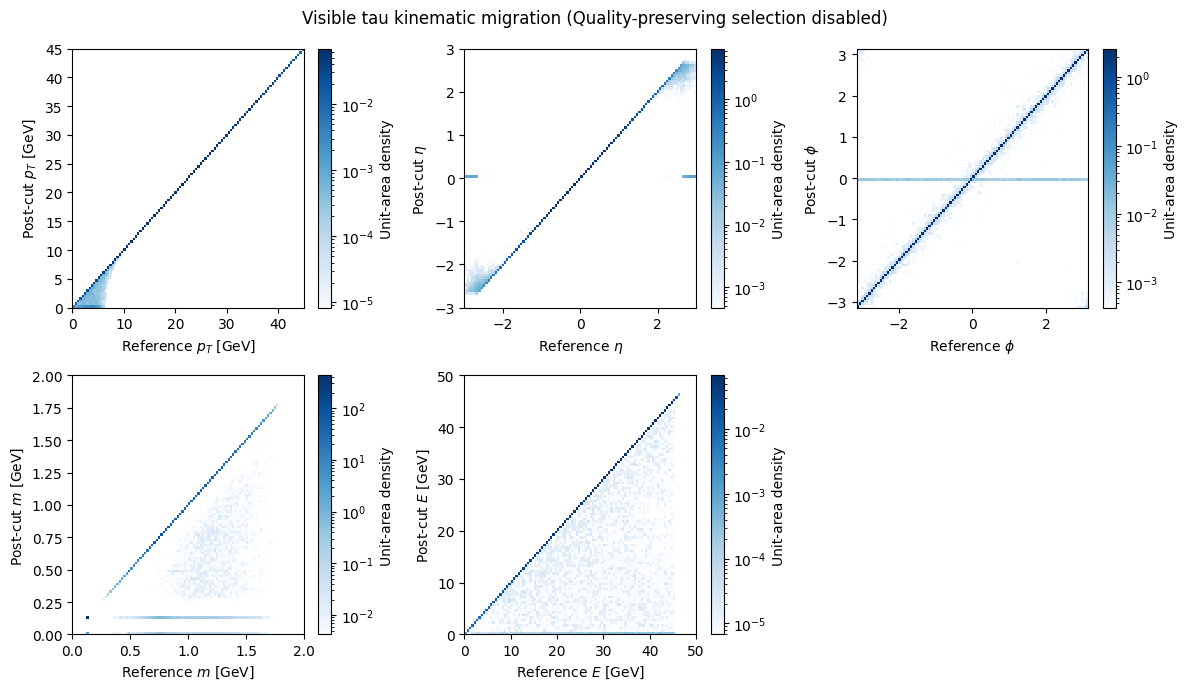

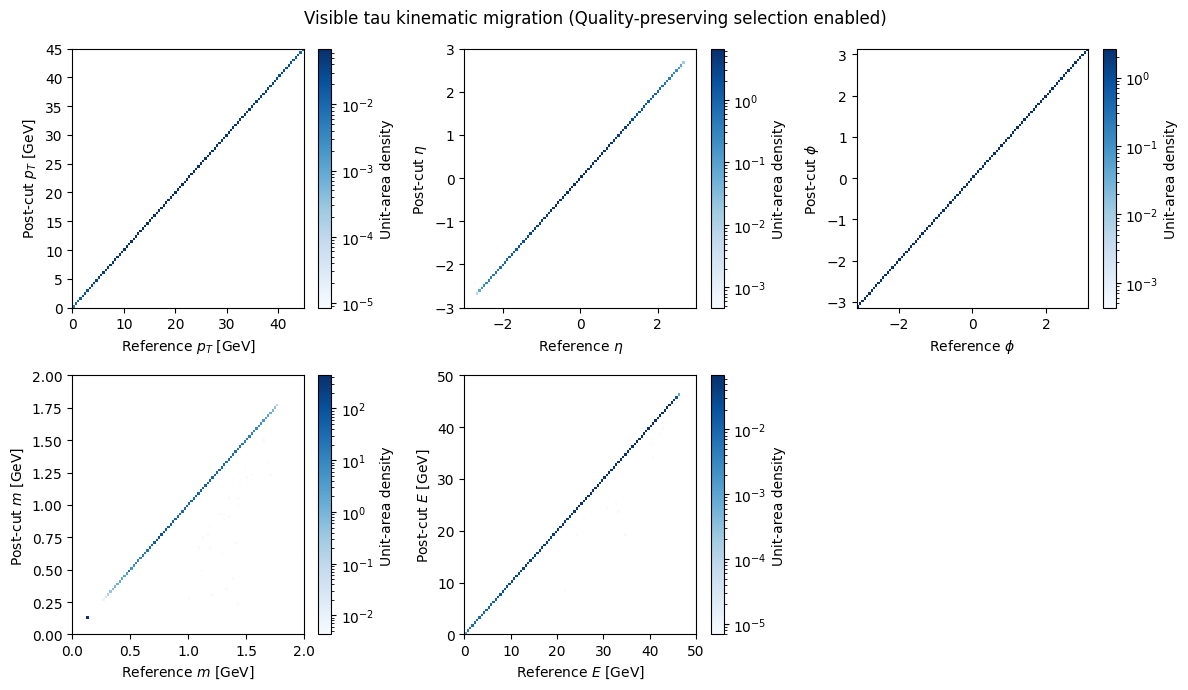

In [14]:
for apply_quality_masks, (reference, test) in samples.items():
    quality_selection = (
        "Quality-preserving selection enabled"
        if apply_quality_masks
        else "Quality-preserving selection disabled"
    )
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for ax, variable in zip(axes.flat, variables):
        bins = migration_bins[variable]
        migration, xedges, yedges = np.histogram2d(
            reference[variable], test[variable], bins=(bins, bins), density=True
        )
        migration = np.ma.masked_where(migration == 0, migration)
        cmap = plt.colormaps["Blues"].copy()
        cmap.set_bad("white")
        image = ax.pcolormesh(
            xedges,
            yedges,
            migration.T,
            cmap=cmap,
            norm=LogNorm(vmin=migration.min(), vmax=migration.max()),
            shading="auto",
        )
        fig.colorbar(image, ax=ax, label="Unit-area density")
        ax.set(
            xlabel=f"Reference {variable_labels[variable]}",
            ylabel=f"Post-cut {variable_labels[variable]}",
        )
    axes.flat[-1].set_visible(False)
    fig.suptitle(f"Visible tau kinematic migration ({quality_selection})")
    fig.tight_layout()
    plt.show()
    plt.close()

/tmp/ipykernel_3060540/1271275315.py:17: RuntimeWarning: divide by zero encountered in log
  "pt": np.log(test["pt"] / reference["pt"]),
/tmp/ipykernel_3060540/1271275315.py:23: RuntimeWarning: divide by zero encountered in log
  "mass": np.log(test["mass"] / reference["mass"]),
/tmp/ipykernel_3060540/1271275315.py:24: RuntimeWarning: divide by zero encountered in log
  "energy": np.log(test["energy"] / reference["energy"]),


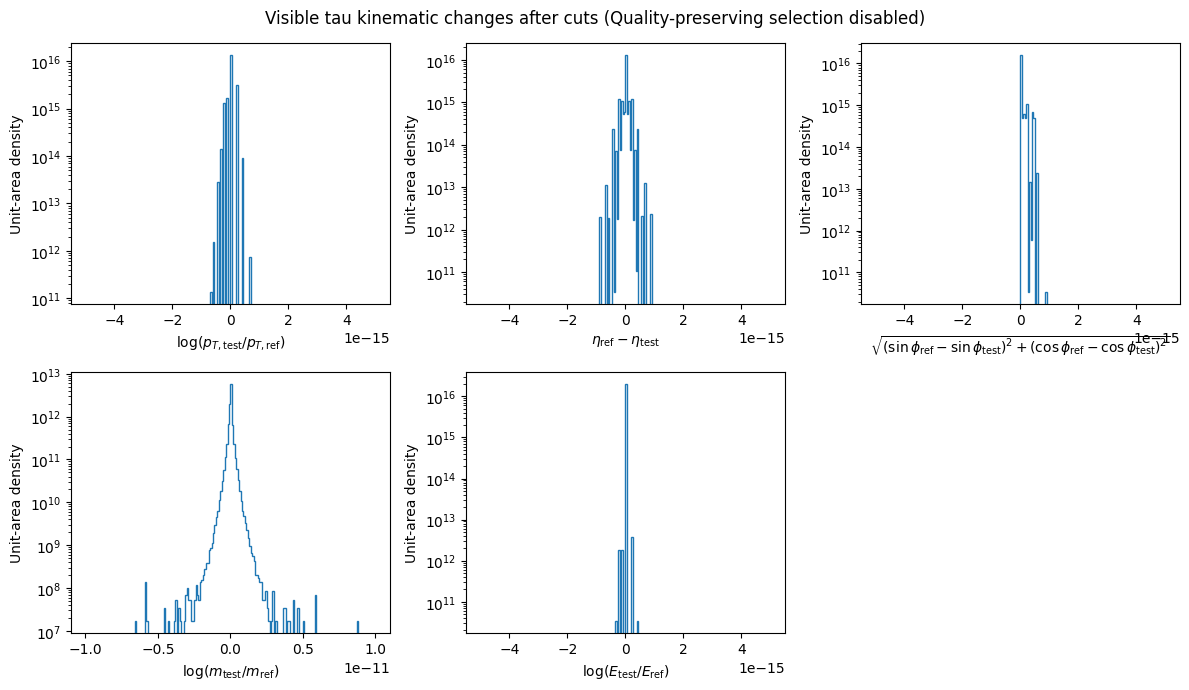

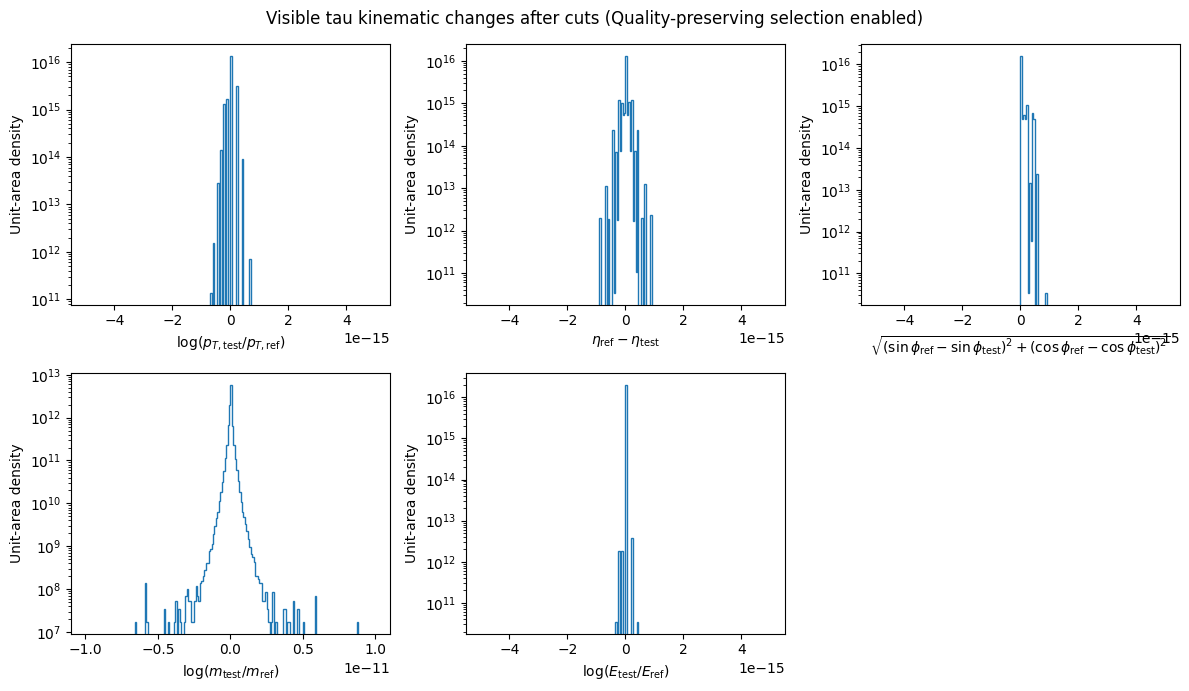

In [15]:
difference_labels = {
    "pt": r"$\log(p_{T, \mathrm{test}} / p_{T, \mathrm{ref}})$",
    "eta": r"$\eta_{\mathrm{ref}} - \eta_{\mathrm{test}}$",
    "phi": r"$\sqrt{(\sin\phi_\mathrm{ref} - \sin\phi_\mathrm{test})^2 + (\cos\phi_\mathrm{ref} - \cos\phi_\mathrm{test})^2}$",
    "mass": r"$\log(m_\mathrm{test} / m_\mathrm{ref})$",
    "energy": r"$\log(E_\mathrm{test} / E_\mathrm{ref})$",
}


for apply_quality_masks, (reference, test) in samples.items():
    quality_selection = (
        "Quality-preserving selection enabled"
        if apply_quality_masks
        else "Quality-preserving selection disabled"
    )
    differences = {
        "pt": np.log(test["pt"] / reference["pt"]),
        "eta": reference["eta"] - test["eta"],
        "phi": np.hypot(
            np.sin(reference["phi"]) - np.sin(test["phi"]),
            np.cos(reference["phi"]) - np.cos(test["phi"]),
        ),
        "mass": np.log(test["mass"] / reference["mass"]),
        "energy": np.log(test["energy"] / reference["energy"]),
    }

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for ax, variable in zip(axes.flat, variables):
        values = differences[variable]
        ax.hist(
            values[np.isfinite(values)],
            bins=200,
            range=(-1e-11, 1e-11) if variable == "mass" else (-5e-15, 5e-15),
            density=True,
            histtype="step",
        )
        ax.set_yscale("log")
        ax.set(xlabel=difference_labels[variable], ylabel="Unit-area density")
    axes.flat[-1].set_visible(False)
    fig.suptitle(f"Visible tau kinematic changes after cuts ({quality_selection})")
    fig.tight_layout()
    plt.show()
    plt.close()

### Conclusion

We'd lose about 1.3% of the taus due to kinematic cuts on generator-level visible tau decay products.
If we now require the charges and decay modes to not change after the kinematic cuts, we would then lose about 1.6% of the taus.
The latter so-called quality requirement ensures that the differences between visible tau decay products before the kinematic cuts and after the kinematic cuts in $p_T$, $\eta$, $\phi$, energy and mass of the visible tau stay negligible.

We should apply both of these requirements (i.e., kinematic cuts and quality requirement) to generator-level visible tau decay products in the training dataset, but only the kinematic cuts when running the inference.
This ensures that we train and evaluate the model on relevant examples (ensured by the kinematic cuts), and that the parent constraints remain consistent during the training phase (hence the quality requirement).

## Mass plots

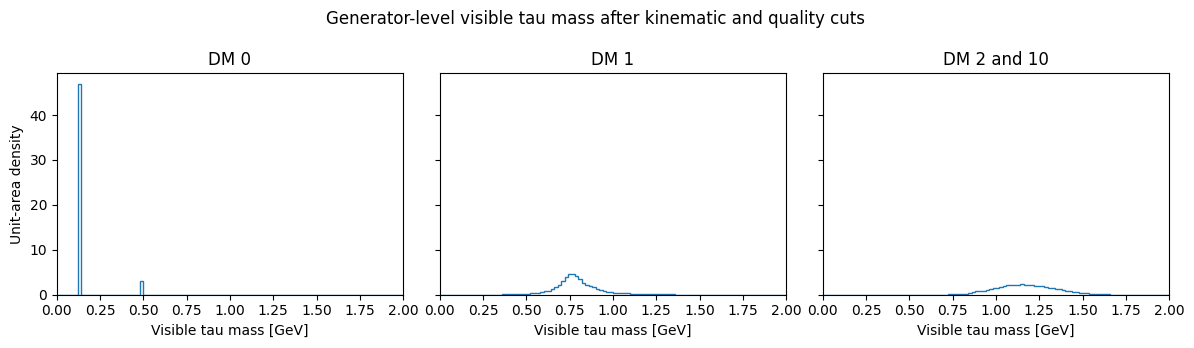

In [16]:
selected_taus = df.loc[kinematic_cut_mask & quality_mask]
decay_mode_groups = {"DM 0": [0], "DM 1": [1], "DM 2 and 10": [2, 10]}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (label, decay_modes) in zip(axes, decay_mode_groups.items()):
    masses = selected_taus.loc[
        selected_taus["gen_tau_dm"].isin(decay_modes), "gen_jet_tau_p4"
    ].map(lambda p4: cartesian_to_p4(p4_to_cartesian(p4))["mass"])
    ax.hist(masses, bins=np.linspace(0, 2, 101), density=True, histtype="step")
    ax.set(title=label, xlabel=r"Visible tau mass [GeV]")
    ax.set_xlim(0, 2)
axes[0].set_ylabel("Unit-area density")
fig.suptitle("Generator-level visible tau mass after kinematic and quality cuts")
fig.tight_layout()
plt.show()
plt.close()

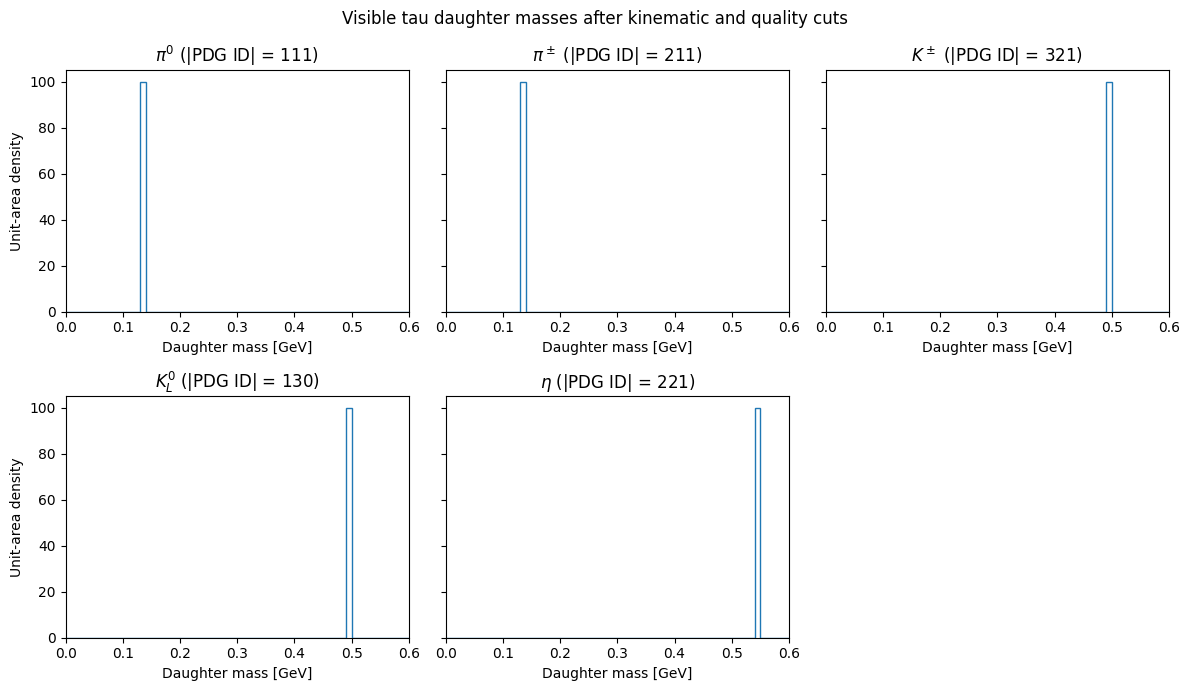

In [17]:
daughter_particle_labels = {
    111: r"$\pi^0$",
    211: r"$\pi^\pm$",
    321: r"$K^\pm$",
    130: r"$K_L^0$",
    221: r"$\eta$",
}
daughter_masses = {pdg_id: [] for pdg_id in daughter_particle_labels}

for daughter_p4s, daughter_pdgs in selected_taus[[
    "gen_jet_tau_vis_daughter_p4s",
    "gen_jet_tau_vis_daughter_pdgs",
]].itertuples(index=False, name=None):
    for daughter_p4, pdg_id, selected in zip(
        daughter_p4s, daughter_pdgs, kinematic_mask(daughter_p4s)
    ):
        if selected and abs(pdg_id) in daughter_masses:
            daughter_masses[abs(pdg_id)].append(
                cartesian_to_p4(p4_to_cartesian(daughter_p4))["mass"]
            )


fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
for ax, (pdg_id, label) in zip(axes.flat, daughter_particle_labels.items()):
    ax.hist(
        daughter_masses[pdg_id],
        bins=np.linspace(0, 1, 101),
        density=True,
        histtype="step",
    )
    ax.set(title=f"{label} (|PDG ID| = {pdg_id})", xlabel="Daughter mass [GeV]")
    ax.set_xlim(0, 0.6)
axes[0, 0].set_ylabel("Unit-area density")
axes[1, 0].set_ylabel("Unit-area density")
axes.flat[-1].set_visible(False)
fig.suptitle("Visible tau daughter masses after kinematic and quality cuts")
fig.tight_layout()
plt.show()
plt.close()

## Optimal observables

TBD.